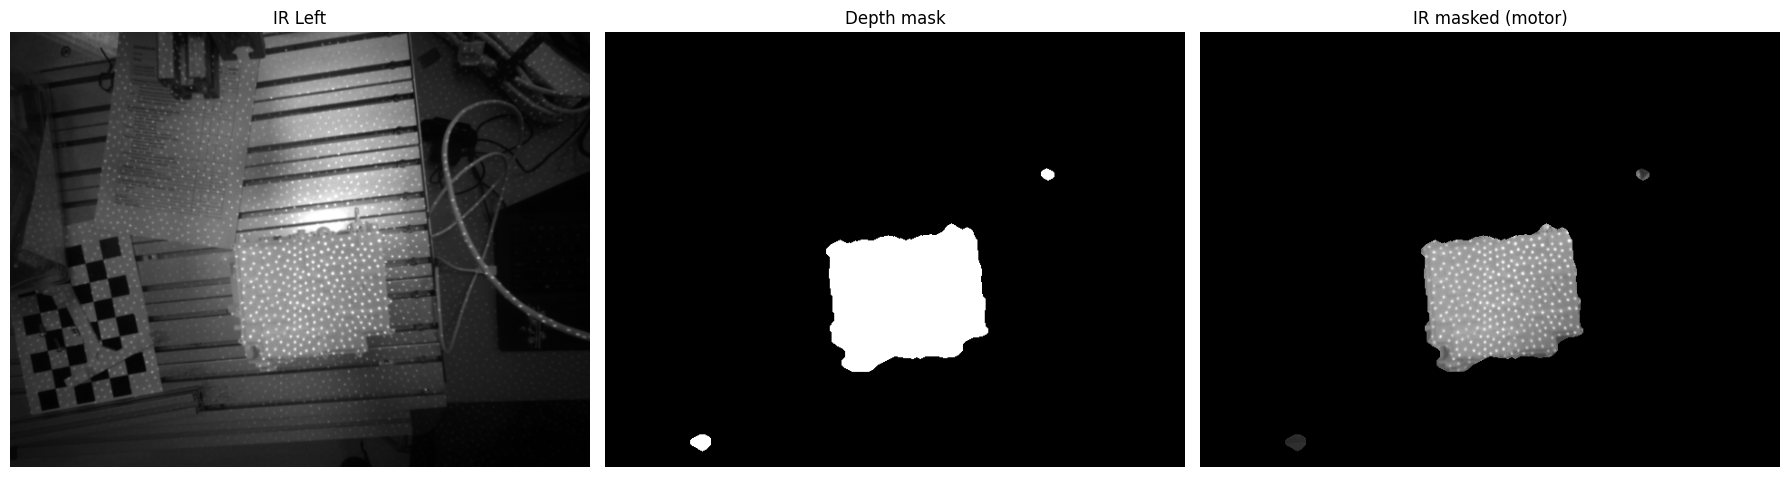

Depth range in image: 200 – 11677 mm


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

IR_PATH    = "../data/ir_left_20260331_111721.png"
DEPTH_PATH = "../data/depth_20260331_111721.npy"

ir    = cv2.imread(IR_PATH, cv2.IMREAD_GRAYSCALE)
depth = np.load(DEPTH_PATH)

# Tightened to motor surface only
NEAR_MM = 280
FAR_MM  = 450

depth_mask = ((depth > NEAR_MM) & (depth < FAR_MM)).astype(np.uint8) * 255

kernel     = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
depth_mask = cv2.morphologyEx(depth_mask, cv2.MORPH_CLOSE, kernel, iterations=3)
depth_mask = cv2.morphologyEx(depth_mask, cv2.MORPH_OPEN,  kernel, iterations=2)

# Apply depth mask to IR image — only keep motor pixels
ir_masked = cv2.bitwise_and(ir, ir, mask=depth_mask)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(ir,         cmap="gray"); axes[0].set_title("IR Left");          axes[0].axis("off")
axes[1].imshow(depth_mask, cmap="gray"); axes[1].set_title("Depth mask");       axes[1].axis("off")
axes[2].imshow(ir_masked,  cmap="gray"); axes[2].set_title("IR masked (motor)"); axes[2].axis("off")
plt.tight_layout()
plt.show()

print(f"Depth range in image: {depth[depth>0].min():.0f} – {depth.max():.0f} mm")

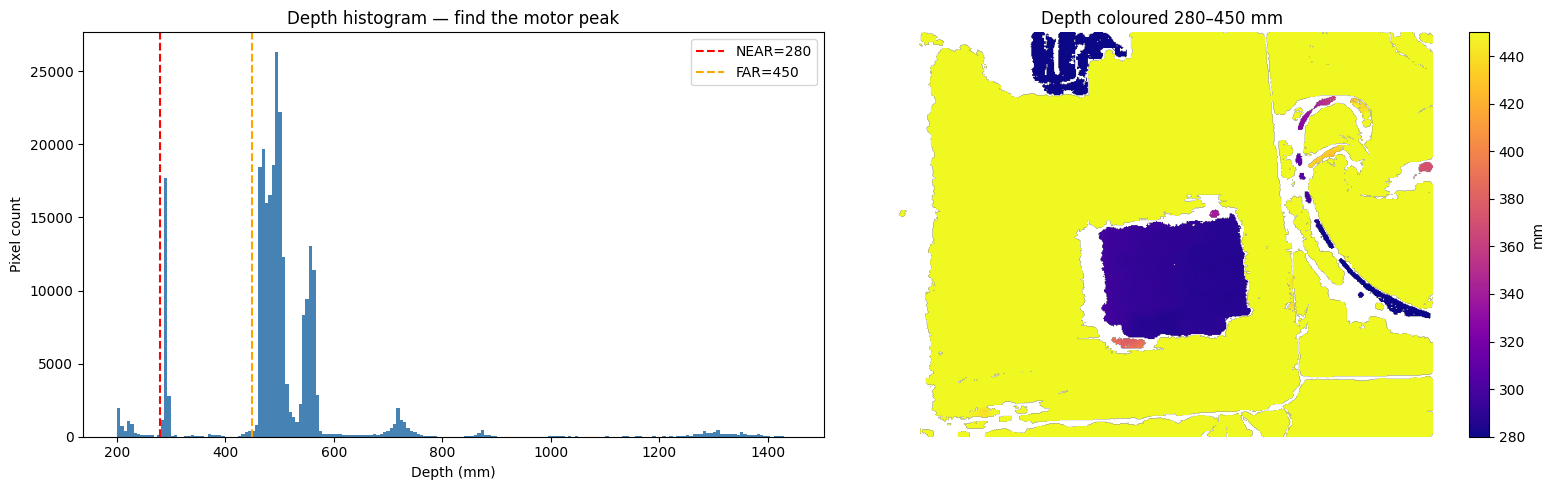

In [22]:
# Depth histogram to find exact motor depth range
valid = depth[(depth > 0) & (depth < 3000)].flatten()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(valid, bins=200, color="steelblue")
axes[0].set_xlabel("Depth (mm)")
axes[0].set_ylabel("Pixel count")
axes[0].set_title("Depth histogram — find the motor peak")
axes[0].axvline(NEAR_MM, color="red",   linestyle="--", label=f"NEAR={NEAR_MM}")
axes[0].axvline(FAR_MM,  color="orange", linestyle="--", label=f"FAR={FAR_MM}")
axes[0].legend()

# Depth image coloured tightly around current range
tight = np.clip(depth, NEAR_MM, FAR_MM).astype(float)
tight[depth == 0] = np.nan  # no-data pixels transparent
im = axes[1].imshow(tight, cmap="plasma", vmin=NEAR_MM, vmax=FAR_MM)
axes[1].set_title(f"Depth coloured {NEAR_MM}–{FAR_MM} mm")
axes[1].axis("off")
plt.colorbar(im, ax=axes[1], label="mm")

plt.tight_layout()
plt.show()

Motor center : (145.5, 138.6)
Orientation  : 77.9° (CCW from right, loop side)


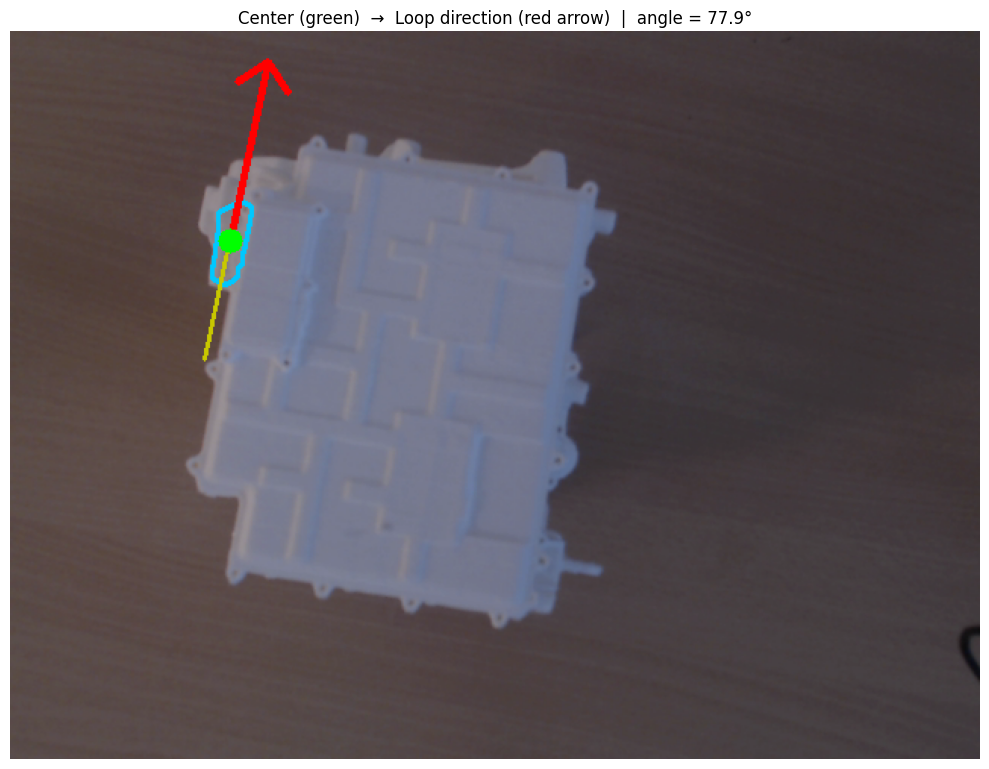

In [13]:
# Find the largest contour = motor
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
motor_contour = max(contours, key=cv2.contourArea)

# --- PCA on mask pixels to get orientation ---
ys, xs = np.where(mask > 0)
pts_f  = np.column_stack([xs, ys]).astype(np.float32)

mean, eigenvectors, eigenvalues = cv2.PCACompute2(pts_f, mean=None)
center = mean[0]                    # (cx, cy)
major  = eigenvectors[0]            # direction of longest axis
minor  = eigenvectors[1]

# --- Disambiguate 180°: which side along the major axis has the loop? ---
# Project all contour points onto the major axis, compare mass on each side
cpts = motor_contour[:, 0, :].astype(float)
proj = (cpts - center) @ major      # signed projection onto major axis

mask_pos = proj >  0
mask_neg = proj <= 0

# The side with more contour area (sum of distances from center) = loop side
weight_pos = np.sum(proj[ mask_pos])
weight_neg = np.sum(-proj[mask_neg])

# Loop is on the heavier side
if weight_pos > weight_neg:
    loop_direction = major
else:
    loop_direction = -major

angle_deg = np.degrees(np.arctan2(-loop_direction[1], loop_direction[0]))

print(f"Motor center : ({center[0]:.1f}, {center[1]:.1f})")
print(f"Orientation  : {angle_deg:.1f}° (CCW from right, loop side)")

# --- Visualise ---
vis = display.copy()
cv2.drawContours(vis, [motor_contour], -1, (0, 200, 255), 2)

cx, cy = int(center[0]), int(center[1])
length = 80

# Major axis (both directions)
p1 = (int(cx + major[0] * length), int(cy + major[1] * length))
p2 = (int(cx - major[0] * length), int(cy - major[1] * length))
cv2.line(vis, p1, p2, (200, 200, 0), 2)

# Loop direction arrow
lp = (int(cx + loop_direction[0] * length * 1.5),
      int(cy + loop_direction[1] * length * 1.5))
cv2.arrowedLine(vis, (cx, cy), lp, (255, 0, 0), 3, tipLength=0.2)

cv2.circle(vis, (cx, cy), 8, (0, 255, 0), -1)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(vis)
ax.set_title(f"Center (green)  →  Loop direction (red arrow)  |  angle = {angle_deg:.1f}°")
ax.axis("off")
plt.tight_layout()
plt.show()